## 1. IMPORTS

In [7]:
import pandas as pd
import numpy as np
import os
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import pickle

## 2. LOAD DATA 

In [8]:
file_path = r"C:\Users\ankit\Desktop\ML project 2\SPAM.csv"

df = pd.read_csv(file_path, encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 3. EDA (Visualization)

label
ham     4825
spam     747
Name: count, dtype: int64


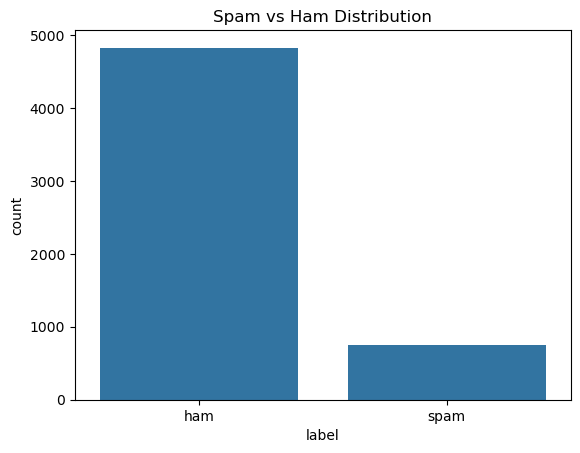

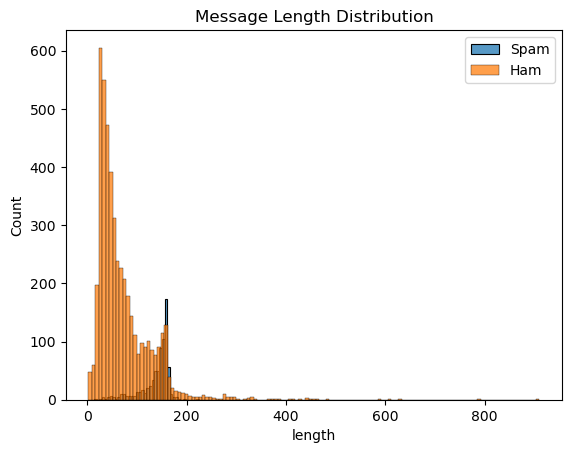

In [9]:
print(df['label'].value_counts())

sns.countplot(x=df['label'])
plt.title("Spam vs Ham Distribution")
plt.show()

df['length'] = df['message'].apply(len)

sns.histplot(df[df['label']=='spam']['length'], label='Spam')
sns.histplot(df[df['label']=='ham']['length'], label='Ham')
plt.legend()
plt.title("Message Length Distribution")
plt.show()

## 4. TEXT PREPROCESSING

In [10]:
nltk.download('stopwords')
ps = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = ''.join([c for c in text if c not in string.punctuation])
    
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]
    
    return ' '.join(words)

df['clean_message'] = df['message'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 5. LABEL ENCODING

In [11]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

## 6. TRAIN TEST SPLIT

In [12]:
X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 7. PIPELINE 

In [13]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('model', LogisticRegression())
])

## 8. HYPERPARAMETER TUNING

In [15]:
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['liblinear']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Params: {'model__C': 10, 'model__solver': 'liblinear'}


## 9. MODEL EVALUATION

In [16]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9865470852017937
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.90      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



## 10. CONFUSION MATRIX

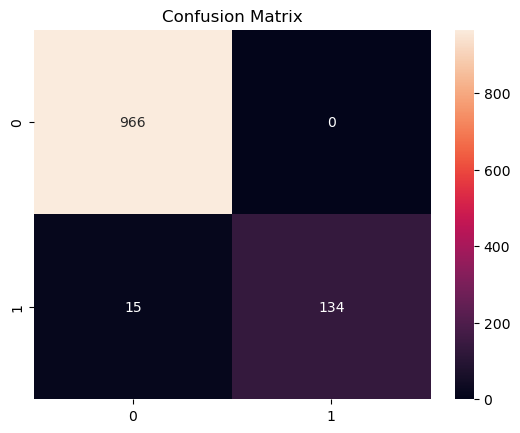

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## 11. MULTIPLE MODEL COMPARISON

In [18]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "SVM": LinearSVC()
}

for name, model in models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000)),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    print(f"{name} Accuracy:", accuracy_score(y_test, preds))

Naive Bayes Accuracy: 0.9695067264573991
Logistic Regression Accuracy: 0.967713004484305
SVM Accuracy: 0.9874439461883409


## 12. SAVE MODEL


In [19]:
os.makedirs("models", exist_ok=True)

pickle.dump(best_model, open("models/spam_pipeline.pkl", "wb"))

## 13. ADVANCED PREDICTION

In [20]:
def predict_sms(text):
    pred = best_model.predict([text])[0]
    
    try:
        prob = best_model.predict_proba([text])[0][1]
    except:
        prob = "N/A"
    
    return {
        "Message": text,
        "Prediction": "Spam" if pred == 1 else "Ham",
        "Confidence": prob
    }

print(predict_sms("Win a FREE iPhone now!!!"))

{'Message': 'Win a FREE iPhone now!!!', 'Prediction': 'Spam', 'Confidence': 0.7000449738580423}


## 14. BATCH TESTING

In [21]:
test_msgs = [
    "Congratulations! You won a prize",
    "Let's meet tomorrow bro",
    "URGENT! Claim reward now",
    "Free entry in 2 lakh contest"
]

for msg in test_msgs:
    print(predict_sms(msg))

{'Message': 'Congratulations! You won a prize', 'Prediction': 'Spam', 'Confidence': 0.8854894303534816}
{'Message': "Let's meet tomorrow bro", 'Prediction': 'Ham', 'Confidence': 0.006474641703681327}
{'Message': 'URGENT! Claim reward now', 'Prediction': 'Spam', 'Confidence': 0.9659851909652784}
{'Message': 'Free entry in 2 lakh contest', 'Prediction': 'Spam', 'Confidence': 0.7096828816489891}
